In [1]:
from src.utils import get_path, set_device, find_closest_power_of_2, get_diffusion_schedule_nickname
from src.QDDPM_torch_angel import WassDistance
import torch
import numpy as np
import matplotlib.pyplot as plt
from functools import partial
from tqdm import tqdm
import yaml
from pathlib import Path

# Actually read the config
modeldir = Path('results_UNet/MNIST_1/modelresults_linear-slope1.3_N1000_M256_n8_T40')
with open(modeldir/'config.yaml') as f:
    config = yaml.safe_load(f)

# n_qubits = int(config["dataset"]["name"].split('_')[1])
n_features = config['dataset']['transforms']['resize']**2

n_data = config['dataset']['maxsize']
n_timesteps = config['model']['n_timesteps']
diffusion_schedule = get_diffusion_schedule_nickname(config)
_, n_qubits = find_closest_power_of_2(n_features, return_power=True)

seed = config['seed']
device = set_device(config.get('device', 'cpu'))
torch.set_default_device(device)
get_path_partial = partial(get_path, config, modeltype='UNet', diffusion_schedule_nickname=diffusion_schedule, n_data=n_data, n_features=n_features, n_qubits=n_qubits, n_timesteps=n_timesteps)
n_limit=0

I0000 00:00:1774973130.740215 1016942 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1774973131.788832 1016942 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
Please first ``pip install -U qiskit`` to enable related functionality in translation module
Please first ``pip install -U cirq`` to enable related functionality in translation module


Using device: cuda:0


In [2]:
# Load the model
from diffusers import UNet1DModel
model = UNet1DModel(sample_size=n_features, **config['model']['unet_config']).to(device)
checkpoint = torch.load(modeldir / 'bestresults/bestmodel.pt', map_location=device)
model_weights = checkpoint['model_state_dict']
model.load_state_dict(model_weights)
model.to(device)
None

/home/angel/miniconda3/envs/dffs/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/tmp/ipykernel_1016942/3551147254.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(modeldir / 'bestresults/bestmodel.pt', map_location=device)


In [3]:
# Compute Wasserstein distance across timesteps
torch.set_default_device(device)

dir, filename = get_path_partial(type='diffusedqstates.npy')
states_diffused = np.load(dir/filename)
print(f"Diffused states shape: {states_diffused.shape}")

# Compute the Wasserstein Distance
wass = np.zeros(n_timesteps+1)
model.eval()
with torch.no_grad():
    inputs_last_timestep = torch.from_numpy(states_diffused[-1]).to(device)
    inputs_last_timestep = torch.view_as_real(inputs_last_timestep) # [T+1, n_data, n_features (real), 2]
    inputs_last_timestep = inputs_last_timestep.permute(0, 2, 1) # [T+1, n_data, n_channels=2, n_features]
        
    inputs_tplus1 = inputs_last_timestep
    inputs_tplus1.to(device)
    for t in tqdm(range(n_timesteps, -1, -1)):
        # t = torch.tensor(t).to(device)
        if t < n_limit:
            continue
        outputs = model(inputs_tplus1, t, return_dict=False)[0]
        norms = torch.sqrt(torch.pow(outputs, 2).sum(dim=1).sum(dim=1))
        pred = outputs / norms.reshape(outputs.shape[0], 1, 1)
        outputs_complex = pred[:,0,:] + pred[:,1,:]*1j # Now re-build the complex tensor

        wass[t] = WassDistance(torch.from_numpy(states_diffused[0]).to(device), outputs_complex).detach().cpu().numpy()
        inputs_tplus1 = outputs
    
dir, filename = get_path_partial(type='wassdistbackwardtrain.npy')
np.save(dir / filename, wass)

# Now of the forward pass
# Wasserstein distance
wassf = np.zeros(n_timesteps+1)
for t in tqdm(range(n_timesteps, -1, -1)):
    if t < n_limit:
        continue
    np.random.seed()
    wassf[t] = WassDistance(torch.from_numpy(states_diffused[0]).to(device), torch.from_numpy(states_diffused[t]).to(device)).detach().cpu().numpy()

dir, filename = get_path_partial(type='wassdistforward.npy')
np.save(dir / filename, wassf)

Diffused states shape: (41, 1000, 256)


  0%|          | 0/41 [00:00<?, ?it/s]

100%|██████████| 41/41 [00:03<00:00, 13.28it/s]


Text(0.5, 1.0, 'Quantum state distribution during the forward and backward processes')

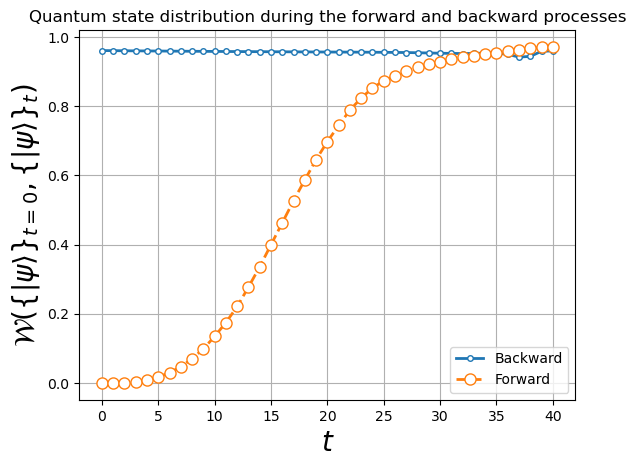

In [4]:
# Plot it

dir, filename = get_path_partial(type='wassdistforward.npy')
wassforward = np.load(dir / filename)
dir, filename = get_path_partial(type='wassdistbackwardtrain.npy')
wassbackwardtrain = np.load(dir / filename)

x = list(range(n_limit, n_timesteps+1))
plt.plot(x, wassbackwardtrain[n_limit:], 'o-', label=f'Backward', mfc='white', markersize=4, lw=2)
plt.plot(x, wassforward[n_limit:], 'o--', label='Forward', mfc='white', markersize=8, lw=2)
plt.ylabel(r'$\mathcal{W}\left(\{|\psi\rangle\}_{t=0}, \{|\psi\rangle\}_{t} \right)$', fontsize=20)
plt.xlabel(r'$t$', fontsize=20)
plt.xticks(range(n_limit,n_timesteps+1, 5))
plt.grid(True)
plt.legend()
plt.title(f'Quantum state distribution during the forward and backward processes')

# Imágenes backward

In [5]:
dir, filename = get_path_partial(type='diffusedqstates.npy')
states_diffused = np.load(dir/filename)
print(states_diffused.shape) # (41, 1000, 256)
with torch.no_grad():
    start_state = torch.from_numpy(states_diffused[-1].copy()).to(device) 
    print(start_state.shape) # [1000, 256]
    inputs_tplus1 = torch.view_as_real(start_state).permute(0, 2, 1)
    print(inputs_tplus1.shape) # [1000, 2, 256]
    inputs_tplus1.to(device)
    outputs_ts = np.zeros((n_timesteps+1, n_data, n_features), dtype=np.complex64)
    outputs_ts[n_timesteps] = states_diffused[-1]
    for t in tqdm(range(n_timesteps, 0, -1)): # From n_timesteps-1 to 1
        # t = torch.tensor(t).to(device)
        if t < n_limit:
            continue
        outputs = model(inputs_tplus1, t, return_dict=False)[0]
        norms = torch.sqrt(torch.pow(outputs, 2).sum(dim=1).sum(dim=1))
        pred = outputs / norms.reshape(outputs.shape[0], 1, 1)
        outputs_complex = pred[:,0,:] + pred[:,1,:]*1j # Now re-build the complex tensor
        outputs_ts[t-1] = outputs_complex.detach().cpu().numpy()

        inputs_tplus1 = outputs


(41, 1000, 256)
torch.Size([1000, 256])
torch.Size([1000, 2, 256])


 10%|█         | 4/40 [00:00<00:01, 32.44it/s]

100%|██████████| 40/40 [00:01<00:00, 28.51it/s]


100%|██████████| 40/40 [00:00<00:00, 2884.32it/s]


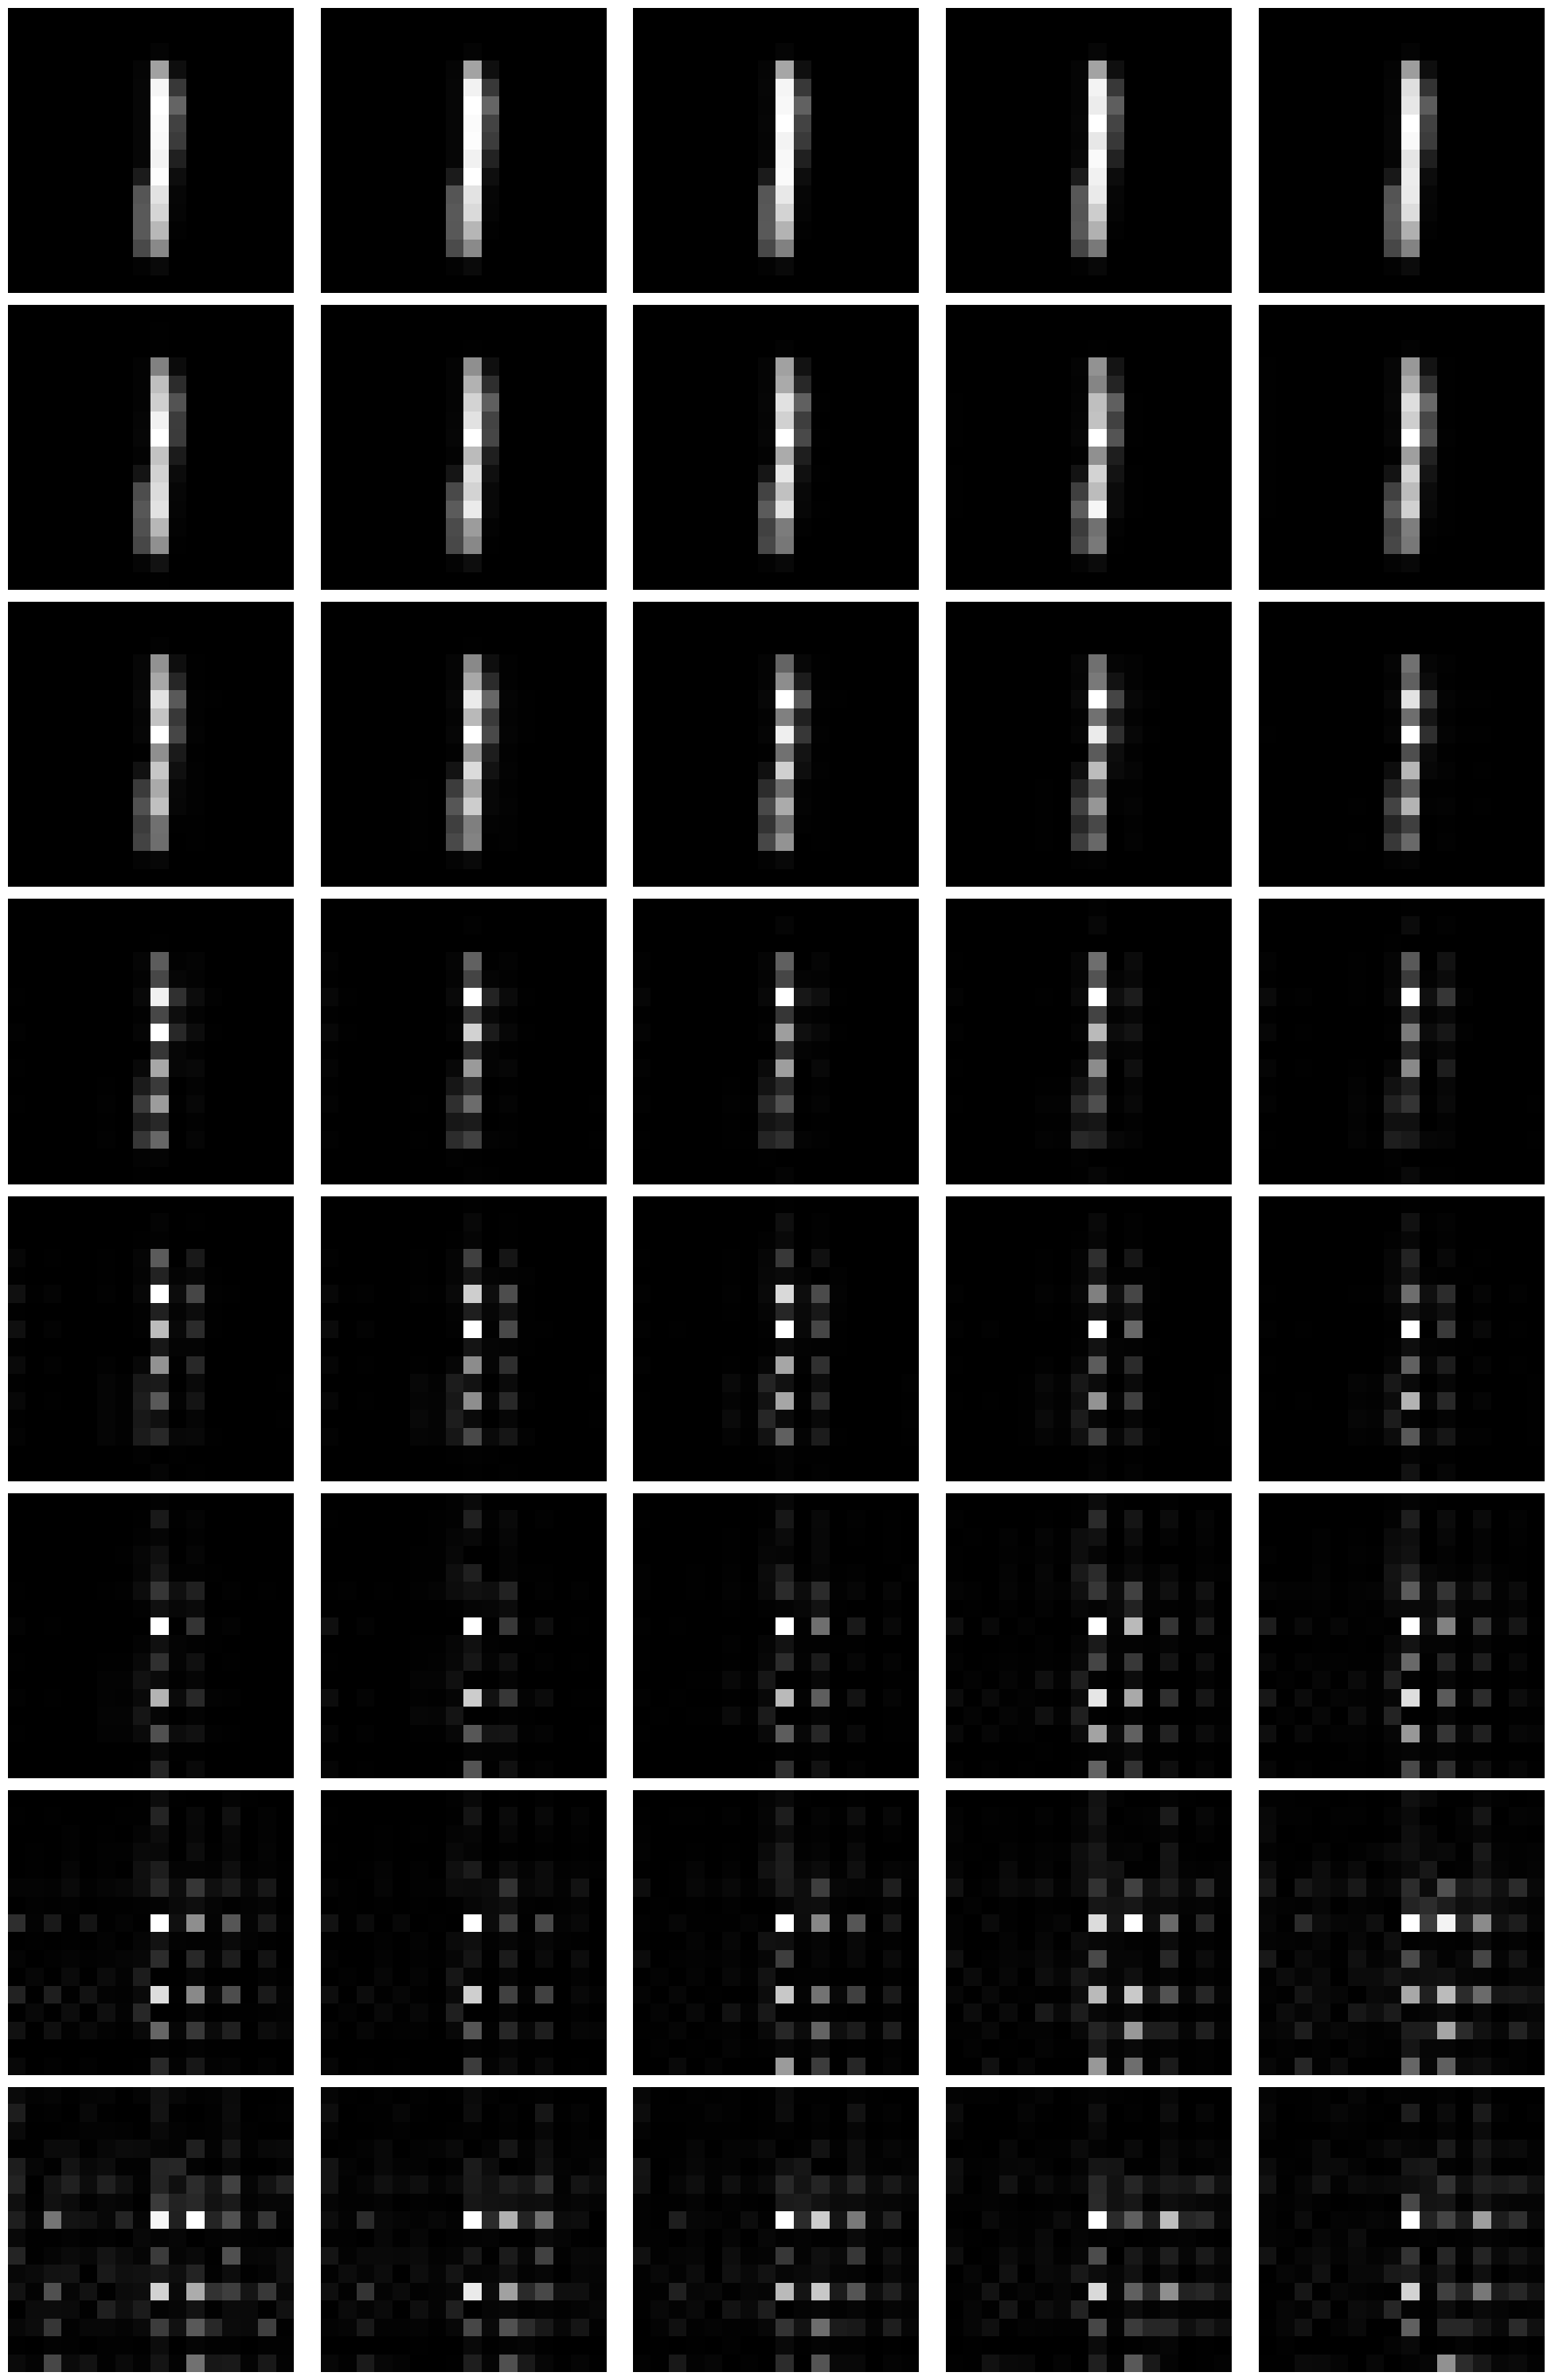

In [58]:
# Plot the evolution of one image
n = 30 # select a sample

image_dim = int(np.sqrt(n_features))
rows = 8
cols = 5
fig, axs = plt.subplots(rows, cols, figsize=(20,30))
vmin, vmax = 0, 1
images = []
for i in tqdm(range(n_timesteps)):
    if i == n_timesteps:
        continue
    # Extract the probabilities and convert back to MNIST digits
    state = outputs_ts[i][n]
    probs = (state*state.conj()).real
    probs = probs[:, np.newaxis][:n_features]
    image = probs.reshape(image_dim, image_dim)

    # Rescale the probabilities to the range [0,1] (although this should already be the case...)
    norm = 1 / image.max()
    image = image * norm

    images.append(image)

    axs[i//cols, i%cols].imshow(image, vmin=vmin, vmax=vmax, cmap='gray')
    axs[i//cols, i%cols].axis('off')

plt.tight_layout()

(-0.5, 15.5, 15.5, -0.5)

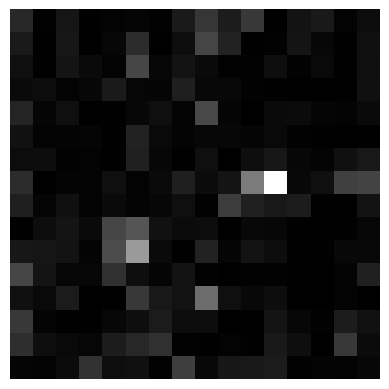

In [33]:
# The last step (full noise)
i = n_timesteps
state = outputs_ts[i][n]
probs = (state*state.conj()).real
probs = probs[:, np.newaxis][:n_features]
image = probs.reshape(image_dim, image_dim)

norm = 1 / image.max()
image = image * norm

images.append(image)

plt.imshow(image, vmin=vmin, vmax=vmax, cmap='gray')
plt.axis('off')

# Images forward

In [29]:
dir, filename = get_path_partial(type='diffusedqstates.npy')
targets = torch.from_numpy(np.load(dir/filename)).to(device) # [T+1, n_data, n_features (complex)]
targets = torch.view_as_real(targets) # [T+1, n_data, n_features (real), 2]
targets = targets.permute(0, 1, 3, 2) # [T+1, n_data, n_channels=2, n_features]
noisy_states = targets[:,:,0,:] + targets[:,:,1,:]*1j # Now re-build the complex tensor
noisy_states = noisy_states.detach().cpu().numpy()
print(noisy_states.shape) # [41, 1000, 256]

(41, 1000, 256)


100%|██████████| 41/41 [00:00<00:00, 2478.30it/s]


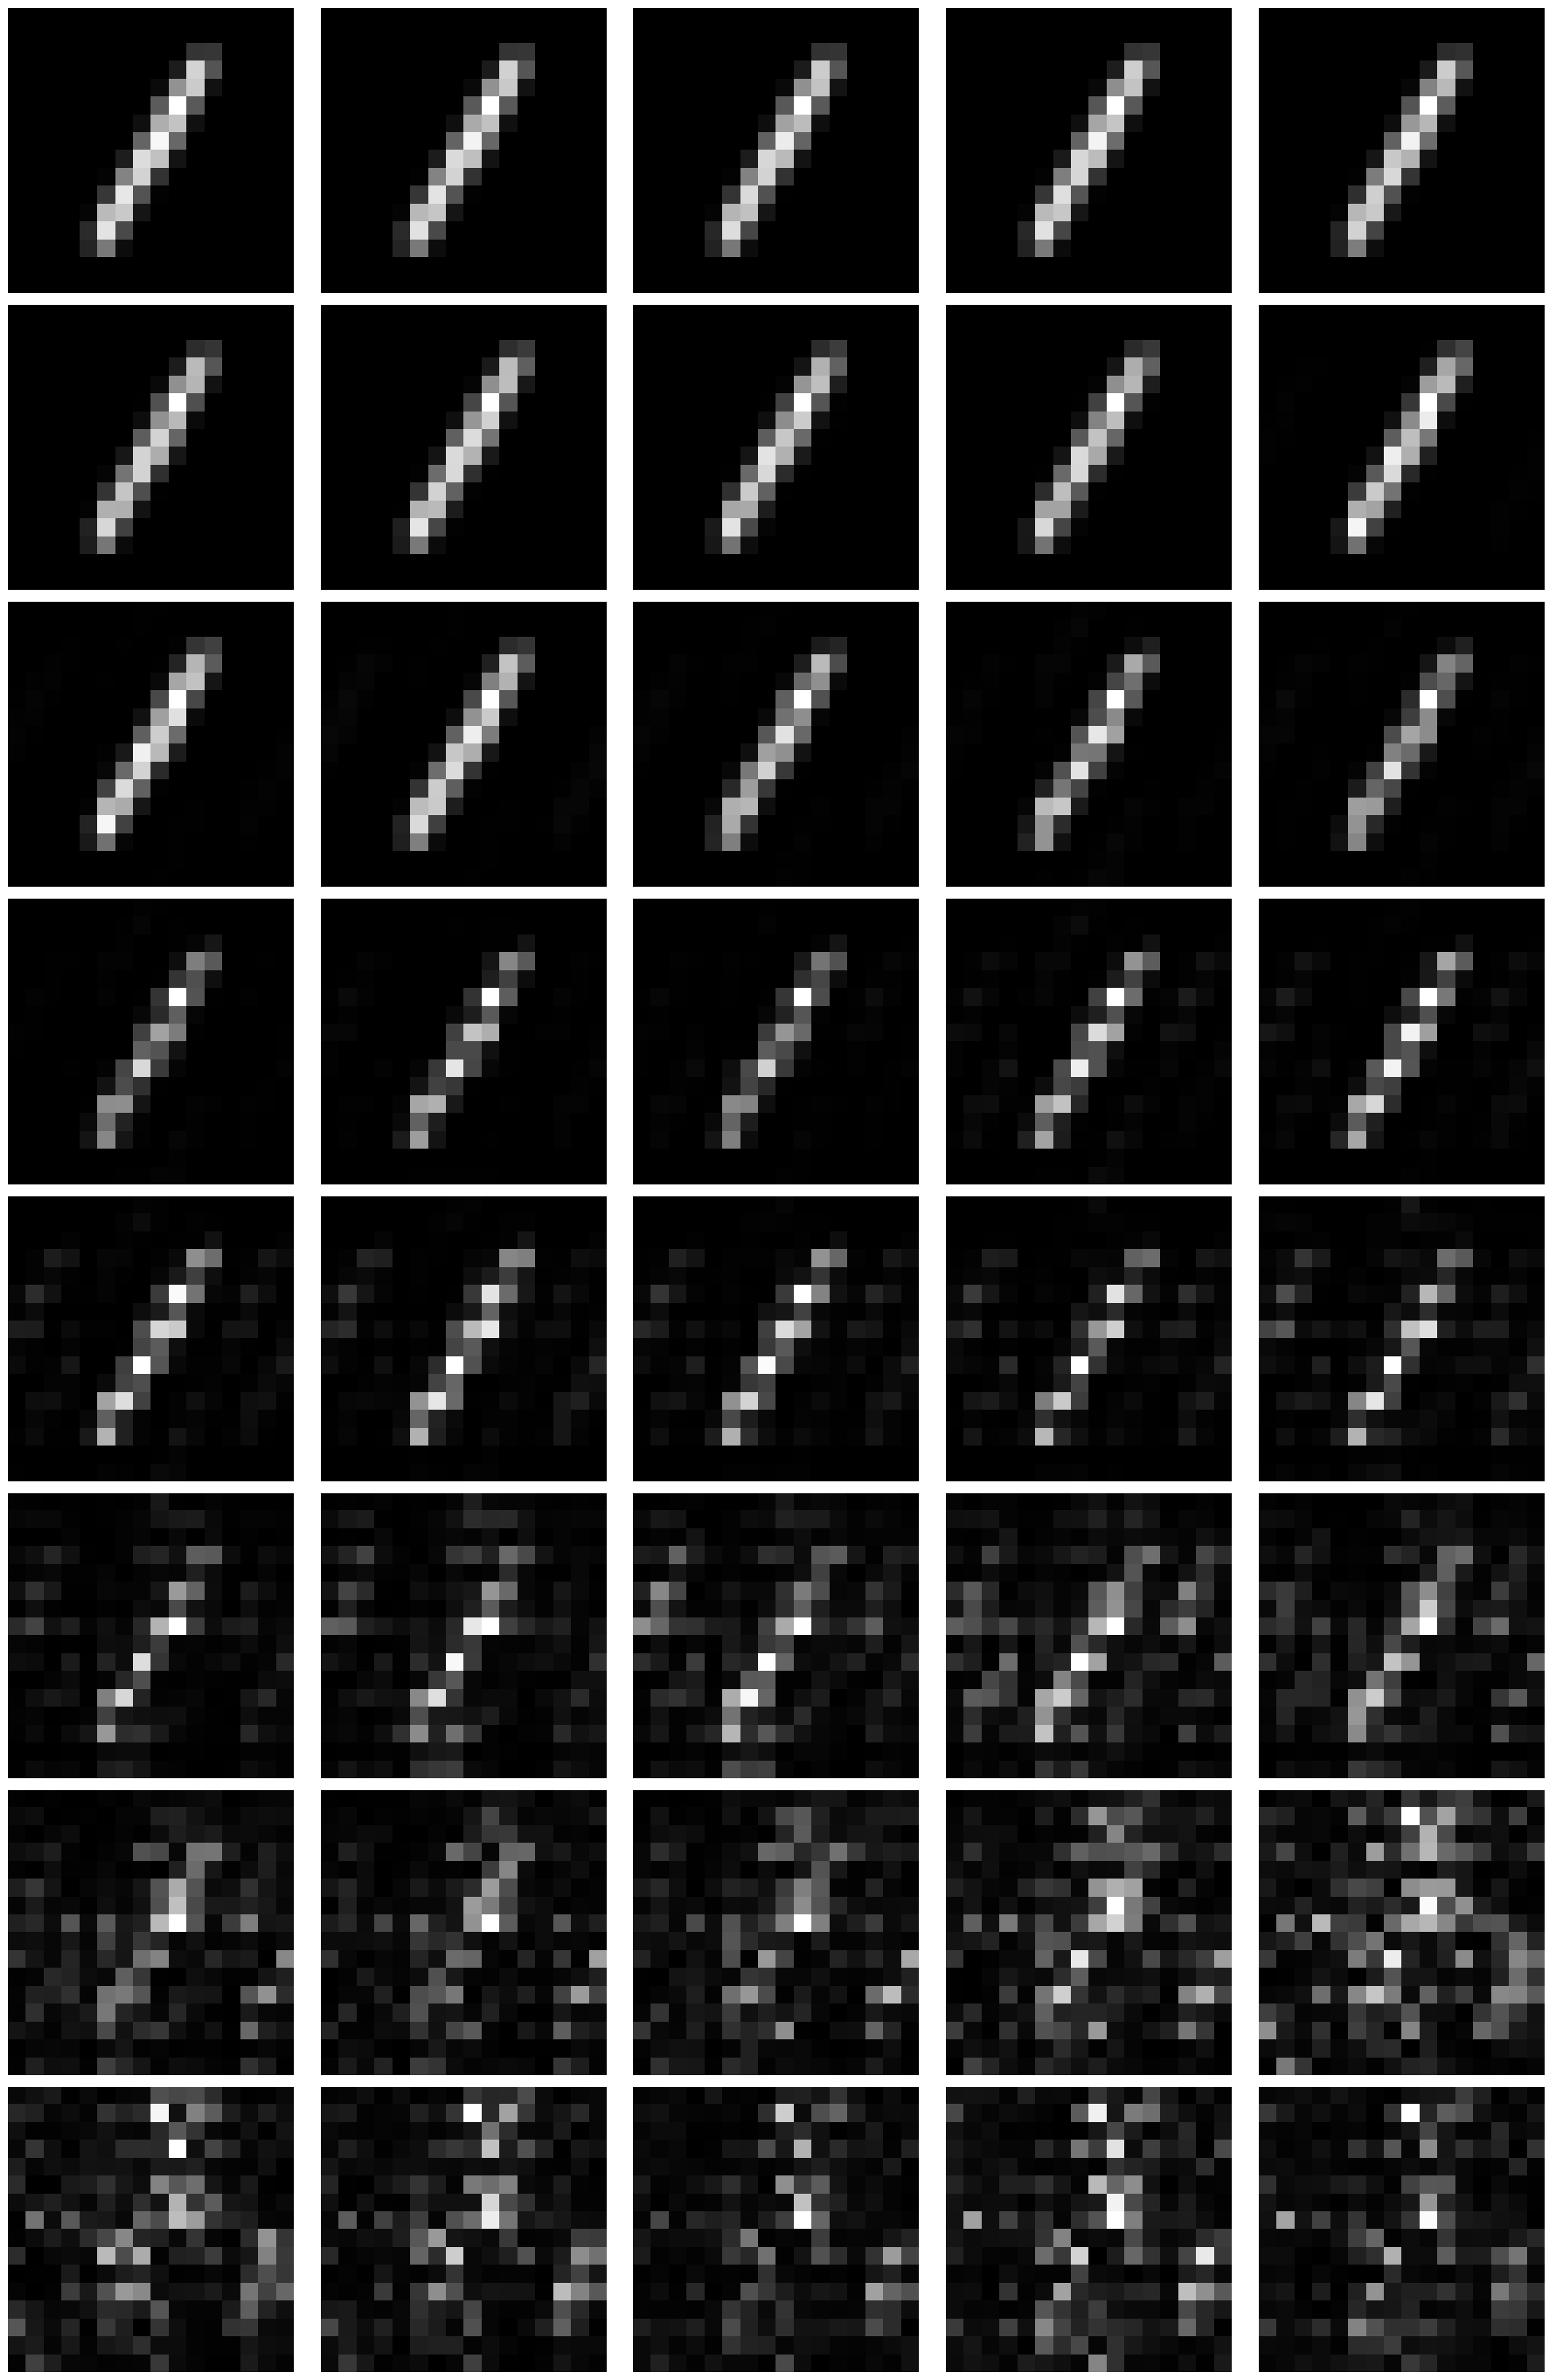

In [30]:
# Plot the evolution of one image
# n = 1 # select a sample

image_dim = int(np.sqrt(n_features))
rows = 8
cols = 5
fig, axs = plt.subplots(rows, cols, figsize=(20,30))
vmin, vmax = 0, 1
images = []
outputs_ts = noisy_states
for i in tqdm(range(n_timesteps+1)):
    if i == n_timesteps:
        continue
    # Extract the probabilities and convert back to MNIST digits
    state = outputs_ts[i][n]
    probs = (state*state.conj()).real
    probs = probs[:, np.newaxis][:n_features]
    image = probs.reshape(image_dim, image_dim)

    # Rescale the probabilities to the range [0,1] (although this should already be the case...)
    norm = 1 / image.max()
    image = image * norm

    images.append(image)

    axs[i//cols, i%cols].imshow(image, vmin=vmin, vmax=vmax, cmap='gray')
    axs[i//cols, i%cols].axis('off')

plt.tight_layout()

(-0.5, 15.5, 15.5, -0.5)

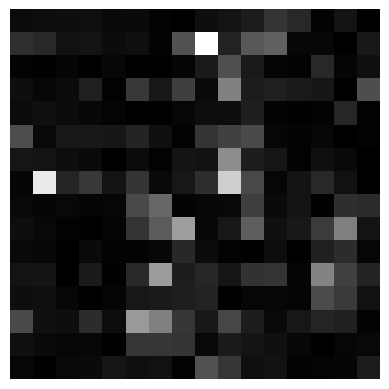

In [31]:
# The last step (full noise)
i = n_timesteps
state = outputs_ts[i][n]
probs = (state*state.conj()).real
probs = probs[:, np.newaxis][:n_features]
image = probs.reshape(image_dim, image_dim)

norm = 1 / image.max()
image = image * norm

images.append(image)

plt.imshow(image, vmin=vmin, vmax=vmax, cmap='gray')
plt.axis('off')

# Loss curves

In [11]:
checkpoint = torch.load(modeldir / 'bestresults/bestmodel.pt', map_location=device)
print(checkpoint.keys())

dict_keys(['model_state_dict', 'optimizer_state_dict', 'lr_scheduler_state_dict', 'epoch', 'best_loss'])


/tmp/ipykernel_1016942/1453638371.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(modeldir / 'bestresults/bestmodel.pt', map_location=device)
